### Environment Setup

In [1]:
import os, sys, json, shutil, datetime
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

print(f"TensorFlow  : {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")
print(f"Devices     : {tf.config.list_physical_devices()}")

2026-03-14 16:36:46.892178: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773506207.283218      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773506207.391574      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773506208.367054      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773506208.367113      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773506208.367116      55 computation_placer.cc:177] computation placer alr

TensorFlow  : 2.19.0
GPU available: True
Devices     : [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


### Configuration

In [6]:
# Paths of the two Datasets 
PLANTDOC_ROOT   = Path("/kaggle/input/datasets/nirmalsankalana/plantdoc-dataset")
PLANTVILLAGE_ROOT = Path("/kaggle/input/datasets/emmarex/plantdisease/PlantVillage") 
WORK_DIR        = Path("/kaggle/working")
DATA_DIR        = WORK_DIR / "data" / "tomato"
MODELS_DIR      = WORK_DIR / "saved_models"
LOGS_DIR        = WORK_DIR / "logs"

for d in [DATA_DIR, MODELS_DIR, LOGS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Hyperparameters 
IMG_SIZE        = (224, 224)
BATCH_SIZE      = 32        
EPOCHS_HEAD     = 15
EPOCHS_FINETUNE = 10
LEARNING_RATE   = 3e-4
FINETUNE_LR     = 1e-5
DROPOUT         = 0.4       
VAL_SPLIT       = 0.2
SEED            = 42

THRESHOLD_CONFIDENT = 0.75
THRESHOLD_UNCERTAIN = 0.50

# PlantDoc class map 
PLANTDOC_CLASS_MAP = {
    "Tomato_Early_blight_leaf"   : "Tomato_Early_Blight",
    "Tomato_Septoria_leaf_spot"  : "Tomato_Septoria_Leaf_Spot",
    "Tomato_leaf"                : "Tomato_Healthy",
    "Tomato_leaf_bacterial_spot" : "Tomato_Bacterial_Spot",
    "Tomato_leaf_late_blight"    : "Tomato_Late_Blight",
    "Tomato_leaf_mosaic_virus"   : "Tomato_Mosaic_Virus",
    "Tomato_leaf_yellow_virus"   : "Tomato_Yellow_Leaf_Curl",
    "Tomato_mold_leaf"           : "Tomato_Leaf_Mold",
}

# PlantVillage class map
PLANTVILLAGE_CLASS_MAP = {
    "Tomato_Bacterial_spot"                  : "Tomato_Bacterial_Spot",
    "Tomato_Early_blight"                    : "Tomato_Early_Blight",
    "Tomato_Late_blight"                     : "Tomato_Late_Blight",
    "Tomato_Leaf_Mold"                       : "Tomato_Leaf_Mold",
    "Tomato_Septoria_leaf_spot"              : "Tomato_Septoria_Leaf_Spot",
    "Tomato__Tomato_YellowLeaf__Curl_Virus"  : "Tomato_Yellow_Leaf_Curl",
    "Tomato__Tomato_mosaic_virus"            : "Tomato_Mosaic_Virus",
    "Tomato_healthy"                         : "Tomato_Healthy",
}

print("Config loaded ✓")
print(f"Canonical classes: {len(set(PLANTDOC_CLASS_MAP.values()))}")

Config loaded ✓
Canonical classes: 8


### Explore Both Datasets

In [7]:
def explore_dataset(root: Path, label: str):
    if not root.exists():
        print(f"{label} not found at {root}")
        return
    print(f"\n{'='*60}")
    print(f"{label}: {root}")
    print(f"{'='*60}")
    all_dirs = [p for p in sorted(root.rglob("*")) if p.is_dir()]
    tomato_total = 0
    for d in all_dirs:
        n = len(list(d.glob("*.*")))
        if n > 0 and d.name.lower().startswith("tomato"):
            marker = "**"
            tomato_total += n
        elif n > 0:
            marker = "  "
        else:
            continue
        print(f"{marker} {d.name:<55} {n:>6} images")
    print(f"\n  Tomato images total: {tomato_total}")

explore_dataset(PLANTDOC_ROOT, "PlantDoc")
explore_dataset(PLANTVILLAGE_ROOT, "PlantVillage")


PlantDoc: /kaggle/input/datasets/nirmalsankalana/plantdoc-dataset
   Apple_Scab_Leaf                                             10 images
   Apple_leaf                                                   9 images
   Apple_rust_leaf                                             10 images
   Bell_pepper_leaf                                             8 images
   Bell_pepper_leaf_spot                                        9 images
   Blueberry_leaf                                              11 images
   Cherry_leaf                                                 10 images
   Corn_Gray_leaf_spot                                          4 images
   Corn_leaf_blight                                            12 images
   Corn_rust_leaf                                              10 images
   Peach_leaf                                                   9 images
   Potato_leaf_early_blight                                    14 images
   Potato_leaf_late_blight                               

### Build Combined Dataset

In [8]:
def copy_images(src_dir: Path, dst_dir: Path, prefix: str, stats: dict):
    dst_dir.mkdir(exist_ok=True)
    copied = 0
    for img_path in src_dir.glob("*"):
        if img_path.suffix.lower() not in [".jpg", ".jpeg", ".png", ".bmp"]:
            continue
        unique_name = f"{prefix}__{img_path.name}"
        shutil.copy2(img_path, dst_dir / unique_name)
        copied += 1
    stats[dst_dir.name] = stats.get(dst_dir.name, 0) + copied
    return copied


def build_combined_dataset(
    plantdoc_root: Path,
    plantvillage_root: Path,
    dst_root: Path,
    plantdoc_map: dict,
    plantvillage_map: dict,
) -> dict:
    if dst_root.exists():
        shutil.rmtree(dst_root)
    dst_root.mkdir(parents=True)

    stats  = {}
    report = {}

    # PlantDoc (pool train + test) 
    pd_copied = 0
    for split in ["train", "test"]:
        split_dir = plantdoc_root / split
        if not split_dir.exists():
            continue
        for src_name, canonical in plantdoc_map.items():
            src_dir = split_dir / src_name
            if not src_dir.exists():
                continue
            n = copy_images(src_dir, dst_root / canonical,
                            prefix=f"pd_{split}", stats=stats)
            pd_copied += n
            report.setdefault(canonical, {})["plantdoc"] = \
                report.get(canonical, {}).get("plantdoc", 0) + n

    # PlantVillage
    pv_copied = 0
    for src_name, canonical in plantvillage_map.items():
        for candidate in [plantvillage_root / src_name,
                          plantvillage_root / "train" / src_name,
                          plantvillage_root / "val"   / src_name]:
            if candidate.exists():
                n = copy_images(candidate, dst_root / canonical,
                                prefix="pv", stats=stats)
                pv_copied += n
                report.setdefault(canonical, {})["plantvillage"] = \
                    report.get(canonical, {}).get("plantvillage", 0) + n
                break   # ← THE ONLY CHANGE: stop after first match

    total = sum(stats.values())
    print(f"PlantDoc images  : {pd_copied}")
    print(f"PlantVillage imgs: {pv_copied}")
    print(f"Total            : {total}\n")
    print(f"{'Class':<40} {'PlantDoc':>10} {'PlantVillage':>13} {'Total':>7}")
    print("-" * 72)
    for cls in sorted(stats.keys()):
        pd_n = report.get(cls, {}).get("plantdoc", 0)
        pv_n = report.get(cls, {}).get("plantvillage", 0)
        bar  = "█" * (stats[cls] // 100)
        print(f"  {cls:<38} {pd_n:>10} {pv_n:>13} {stats[cls]:>7}  {bar}")
    print(f"  {'TOTAL':<38} "
          f"{sum(r.get('plantdoc',0) for r in report.values()):>10} "
          f"{sum(r.get('plantvillage',0) for r in report.values()):>13} "
          f"{total:>7}")
    return stats


class_stats = build_combined_dataset(
    PLANTDOC_ROOT, PLANTVILLAGE_ROOT,
    DATA_DIR,
    PLANTDOC_CLASS_MAP, PLANTVILLAGE_CLASS_MAP,
)

CLASS_NAMES = sorted(class_stats.keys())
NUM_CLASSES = len(CLASS_NAMES)
print(f"\nFinal class list ({NUM_CLASSES} classes):\n{CLASS_NAMES}")

PlantDoc images  : 901
PlantVillage imgs: 12931
Total            : 13832

Class                                      PlantDoc  PlantVillage   Total
------------------------------------------------------------------------
  Tomato_Bacterial_Spot                         110          2127    2237  ██████████████████████
  Tomato_Early_Blight                            88          1000    1088  ██████████
  Tomato_Healthy                                 52          1591    1643  ████████████████
  Tomato_Late_Blight                            111          1909    2020  ████████████████████
  Tomato_Leaf_Mold                               91           952    1043  ██████████
  Tomato_Mosaic_Virus                            54           373     427  ████
  Tomato_Septoria_Leaf_Spot                     157          1771    1928  ███████████████████
  Tomato_Yellow_Leaf_Curl                       238          3208    3446  ██████████████████████████████████
  TOTAL                             

### 

### Data Pipeline

In [9]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.15),
    layers.RandomBrightness(0.15),
], name="augmentation")

train_ds_raw = keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=VAL_SPLIT,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    class_names=CLASS_NAMES,
)

val_ds_raw = keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=VAL_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    class_names=CLASS_NAMES,
)

assert train_ds_raw.class_names == CLASS_NAMES, "Class name mismatch!"
print(f"Train batches : {len(train_ds_raw)}")
print(f"Val batches   : {len(val_ds_raw)}")
print(f"Classes       : {CLASS_NAMES}")

# EfficientNetB0 does its own internal normalization — pass raw [0, 255] pixels
AUTOTUNE = tf.data.AUTOTUNE

def prepare_train(ds):
    return (
        ds
        .map(lambda x, y: (data_augmentation(x, training=True), y),
             num_parallel_calls=AUTOTUNE)
        .cache()
        .shuffle(buffer_size=1000)
        .prefetch(AUTOTUNE)
    )

def prepare_val(ds):
    return ds.cache().prefetch(AUTOTUNE)

train_ds = prepare_train(train_ds_raw)
val_ds   = prepare_val(val_ds_raw)
print("\nDatasets prepared ✓")

I0000 00:00:1773508267.672761      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1773508267.678643      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 13832 files belonging to 8 classes.
Using 11066 files for training.
Found 13832 files belonging to 8 classes.
Using 2766 files for validation.
Train batches : 346
Val batches   : 87
Classes       : ['Tomato_Bacterial_Spot', 'Tomato_Early_Blight', 'Tomato_Healthy', 'Tomato_Late_Blight', 'Tomato_Leaf_Mold', 'Tomato_Mosaic_Virus', 'Tomato_Septoria_Leaf_Spot', 'Tomato_Yellow_Leaf_Curl']

Datasets prepared ✓


### Visual Sanity Check

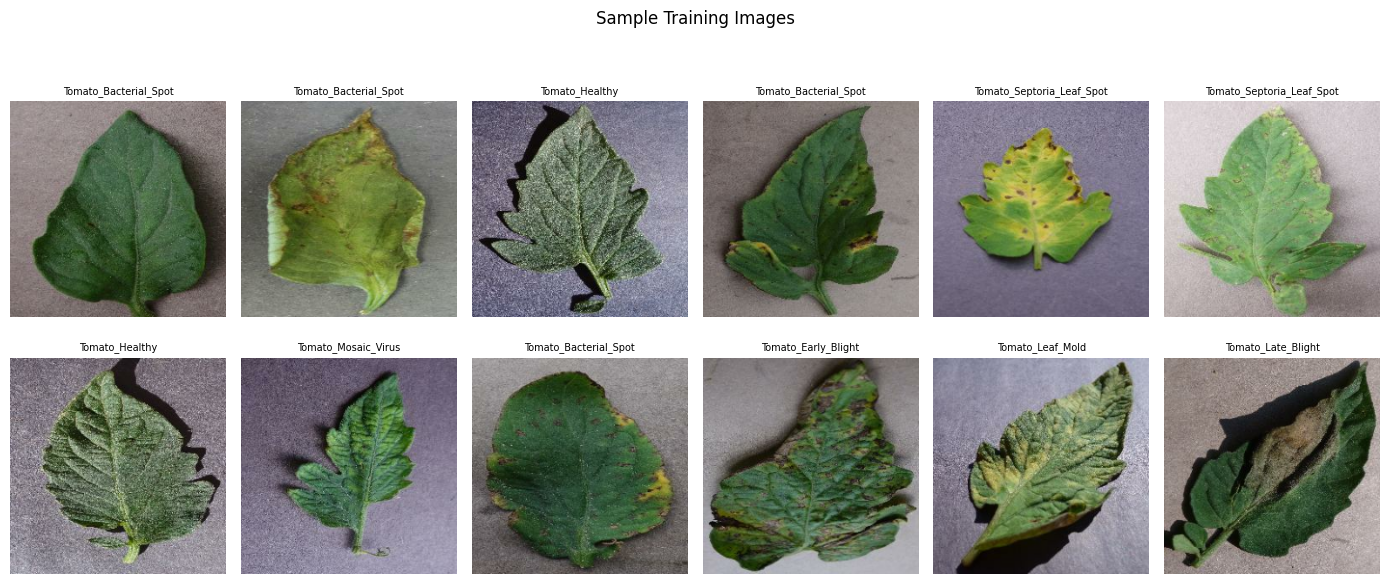

In [10]:
plt.figure(figsize=(14, 6))
for images, labels in train_ds_raw.take(1):
    for i in range(min(12, len(images))):
        ax = plt.subplot(2, 6, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(CLASS_NAMES[labels[i]], fontsize=7)
        plt.axis("off")
plt.suptitle("Sample Training Images", y=1.02)
plt.tight_layout()
plt.savefig(LOGS_DIR / "sample_images.png", bbox_inches="tight")
plt.show()

### Build Model

In [11]:
def build_model(num_classes: int, dropout: float = 0.4):
    base_model = EfficientNetB0(
        input_shape=(*IMG_SIZE, 3),
        include_top=False,
        weights="imagenet",
    )
    base_model.trainable = False

    inputs  = keras.Input(shape=(*IMG_SIZE, 3))
    x       = base_model(inputs, training=False)
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.BatchNormalization()(x)
    x       = layers.Dropout(dropout)(x)
    x       = layers.Dense(
                  256, activation="relu",
                  kernel_regularizer=keras.regularizers.l2(1e-4)
              )(x)
    x       = layers.Dropout(dropout / 2)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs, outputs, name="tomato_efficientnetb0")
    return model, base_model

model, base_model = build_model(NUM_CLASSES, DROPOUT)

model.compile(
    optimizer=keras.optimizers.Adam(LEARNING_RATE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary(show_trainable=True)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "tomato_efficientnetb0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_2 (InputLayer)  │ (None, 224, 224, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ efficientnetb0 (Functional) │ (None, 7, 7, 1280)    │  4,049,571 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_average_pooling2d    │ (None, 1280)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ batch_normalization         │ (None, 1280)          │      5,120 │   Y   │
│ (BatchNormalization)        │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout (Dropout)           │ (None, 1280)          │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense (Dense)               │ (None, 256)           │    327,936 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout_1 (Dropout)         │ (None, 256)           │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_1 (Dense)             │ (None, 8)             │      2,056 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 4,384,683 (16.73 MB)

 Trainable params: 332,552 (1.27 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

### Class Weights

In [12]:
all_train_labels = np.concatenate([y.numpy() for _, y in train_ds_raw])

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=all_train_labels,
)
class_weight_dict = dict(enumerate(class_weights_array))

print("Class weights:")
for i, cls in enumerate(CLASS_NAMES):
    print(f"  {cls:<40}  weight = {class_weight_dict[i]:.3f}")

Class weights:
  Tomato_Bacterial_Spot                     weight = 0.769
  Tomato_Early_Blight                       weight = 1.568
  Tomato_Healthy                            weight = 1.046
  Tomato_Late_Blight                        weight = 0.855
  Tomato_Leaf_Mold                          weight = 1.691
  Tomato_Mosaic_Virus                       weight = 4.009
  Tomato_Septoria_Leaf_Spot                 weight = 0.894
  Tomato_Yellow_Leaf_Curl                   weight = 0.506


### Phase 1: Train Head Only

In [13]:
callbacks_phase1 = [
    EarlyStopping(monitor="val_accuracy", patience=6,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.3,
                      patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint(filepath=str(MODELS_DIR / "best_phase1.keras"),
                    monitor="val_accuracy", save_best_only=True, verbose=1),
]

print("=" * 60)
print("PHASE 1  Training classification head (base frozen)")
print("=" * 60)

history_phase1 = model.fit(
    train_ds,
    epochs=EPOCHS_HEAD,
    validation_data=val_ds,
    class_weight=class_weight_dict,
    callbacks=callbacks_phase1,
)

PHASE 1  Training classification head (base frozen)
Epoch 1/15


I0000 00:00:1773508387.120309     143 service.cc:152] XLA service 0x7958c4009df0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773508387.120358     143 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1773508387.120366     143 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1773508389.616717     143 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-03-14 17:13:17.922508: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-14 17:13:18.065555: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-14 17:13:18.404744: E external/local_xl

158/346 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - accuracy: 0.4306 - loss: 1.8762

2026-03-14 17:13:39.487572: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-14 17:13:39.629304: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-14 17:13:39.957072: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-14 17:13:40.096332: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-14 17:13:40.800560: E external/local_xla/xla/stream_

345/346 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.5390 - loss: 1.5326

2026-03-14 17:14:09.460293: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-14 17:14:09.599586: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-14 17:14:09.911285: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-14 17:14:10.051459: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-14 17:14:10.741248: E external/local_xla/xla/stream_


Epoch 1: val_accuracy improved from -inf to 0.83189, saving model to /kaggle/working/saved_models/best_phase1.keras
346/346 ━━━━━━━━━━━━━━━━━━━━ 136s 139ms/step - accuracy: 0.5398 - loss: 1.5302 - val_accuracy: 0.8319 - val_loss: 0.5578 - learning_rate: 3.0000e-04
Epoch 2/15
345/346 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8007 - loss: 0.6867
Epoch 2: val_accuracy improved from 0.83189 to 0.85936, saving model to /kaggle/working/saved_models/best_phase1.keras
346/346 ━━━━━━━━━━━━━━━━━━━━ 15s 44ms/step - accuracy: 0.8007 - loss: 0.6866 - val_accuracy: 0.8594 - val_loss: 0.4564 - learning_rate: 3.0000e-04
Epoch 3/15
345/346 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8455 - loss: 0.5183
Epoch 3: val_accuracy improved from 0.85936 to 0.88865, saving model to /kaggle/working/saved_models/best_phase1.keras
346/346 ━━━━━━━━━━━━━━━━━━━━ 15s 44ms/step - accuracy: 0.8455 - loss: 0.5184 - val_accuracy: 0.8886 - val_loss: 0.3809 - learning_rate: 3.0000e-04
Epoch 4/15
345/346 ━━━━━━━━━

### Phase 2: Fine-Tune

In [14]:
# Properly unfreeze top 30 layers of EfficientNetB0
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

trainable_params = sum(tf.size(w).numpy() for w in model.trainable_weights)
frozen_params    = sum(tf.size(w).numpy() for w in model.non_trainable_weights)
print(f"Trainable params : {trainable_params:,}")
print(f"Frozen params    : {frozen_params:,}")

FINE_TUNE_FROM = len(base_model.layers) - 30

model.compile(
    optimizer=keras.optimizers.Adam(FINETUNE_LR),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

callbacks_phase2 = [
    EarlyStopping(monitor="val_accuracy", patience=7,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.3,
                      patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint(filepath=str(MODELS_DIR / "best_phase2.keras"),
                    monitor="val_accuracy", save_best_only=True, verbose=1),
]

print("=" * 60)
print("PHASE 2 - Fine-tuning top 30 layers of EfficientNetB0")
print("=" * 60)

initial_epoch = len(history_phase1.history["loss"])

history_phase2 = model.fit(
    train_ds,
    epochs=initial_epoch + EPOCHS_FINETUNE,
    initial_epoch=initial_epoch,
    validation_data=val_ds,
    class_weight=class_weight_dict,
    callbacks=callbacks_phase2,
)

Trainable params : 1,828,712
Frozen params    : 2,555,971
PHASE 2 - Fine-tuning top 30 layers of EfficientNetB0
Epoch 16/25
346/346 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.7641 - loss: 0.8601
Epoch 16: val_accuracy improved from -inf to 0.86949, saving model to /kaggle/working/saved_models/best_phase2.keras
346/346 ━━━━━━━━━━━━━━━━━━━━ 72s 126ms/step - accuracy: 0.7642 - loss: 0.8598 - val_accuracy: 0.8695 - val_loss: 0.4377 - learning_rate: 1.0000e-05
Epoch 17/25
345/346 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.8185 - loss: 0.5776
Epoch 17: val_accuracy improved from 0.86949 to 0.88033, saving model to /kaggle/working/saved_models/best_phase2.keras
346/346 ━━━━━━━━━━━━━━━━━━━━ 19s 55ms/step - accuracy: 0.8185 - loss: 0.5775 - val_accuracy: 0.8803 - val_loss: 0.4124 - learning_rate: 1.0000e-05
Epoch 18/25
345/346 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.8353 - loss: 0.5230
Epoch 18: val_accuracy improved from 0.88033 to 0.88937, saving model to /kaggle/working/sav

### Training Curves

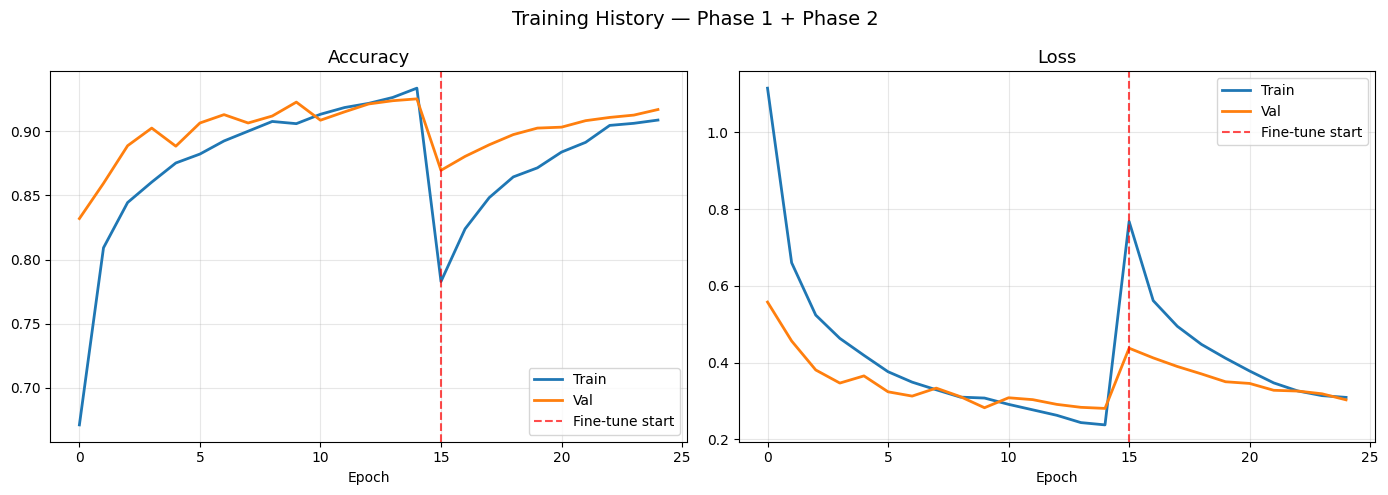


Best val accuracy: 0.9252 (92.5%)


In [15]:
def plot_training_history(h1, h2):
    acc   = h1.history["accuracy"]     + h2.history["accuracy"]
    val   = h1.history["val_accuracy"] + h2.history["val_accuracy"]
    loss  = h1.history["loss"]         + h2.history["loss"]
    vloss = h1.history["val_loss"]     + h2.history["val_loss"]
    boundary = len(h1.history["loss"])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    for ax, tr, vl, title in [
        (ax1, acc, val,   "Accuracy"),
        (ax2, loss, vloss, "Loss"),
    ]:
        ax.plot(tr, label="Train", linewidth=2)
        ax.plot(vl, label="Val",   linewidth=2)
        ax.axvline(x=boundary, color="red", linestyle="--",
                   alpha=0.7, label="Fine-tune start")
        ax.set_title(title, fontsize=13)
        ax.set_xlabel("Epoch")
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.suptitle("Training History — Phase 1 + Phase 2", fontsize=14)
    plt.tight_layout()
    plt.savefig(LOGS_DIR / "training_curves.png", bbox_inches="tight")
    plt.show()

    best_val_acc = max(val)
    print(f"\nBest val accuracy: {best_val_acc:.4f} ({best_val_acc*100:.1f}%)")
    return best_val_acc

best_val_acc = plot_training_history(history_phase1, history_phase2)

### Evaluation

In [16]:
y_true_all, y_pred_all, y_prob_all = [], [], []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_prob_all.extend(preds)
    y_pred_all.extend(np.argmax(preds, axis=1))
    y_true_all.extend(labels.numpy())

y_true = np.array(y_true_all)
y_pred = np.array(y_pred_all)
y_prob = np.array(y_prob_all)

print(f"Evaluated on {len(y_true)} validation images\n")

report_str  = classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=3)
report_dict = classification_report(y_true, y_pred, target_names=CLASS_NAMES, output_dict=True)

print("Per-Class Classification Report")
print("=" * 70)
print(report_str)

print("Classes with F1 < 0.65:")
weak = False
for cls, m in report_dict.items():
    if isinstance(m, dict) and m.get("f1-score", 1.0) < 0.65:
        print(f"   {cls:<40} F1={m['f1-score']:.3f}  support={int(m['support'])}")
        weak = True
if not weak:
    print("   None - all classes above threshold ")

Evaluated on 2766 validation images

Per-Class Classification Report
                           precision    recall  f1-score   support

    Tomato_Bacterial_Spot      0.949     0.852     0.898       438
      Tomato_Early_Blight      0.854     0.820     0.837       206
           Tomato_Healthy      0.888     0.988     0.935       321
       Tomato_Late_Blight      0.901     0.948     0.924       403
         Tomato_Leaf_Mold      0.936     0.840     0.885       225
      Tomato_Mosaic_Virus      0.745     0.854     0.795        82
Tomato_Septoria_Leaf_Spot      0.861     0.916     0.888       380
  Tomato_Yellow_Leaf_Curl      0.991     0.968     0.979       711

                 accuracy                          0.917      2766
                macro avg      0.891     0.898     0.893      2766
             weighted avg      0.920     0.917     0.917      2766

Classes with F1 < 0.65:
   None - all classes above threshold 


### Confusion Matrix

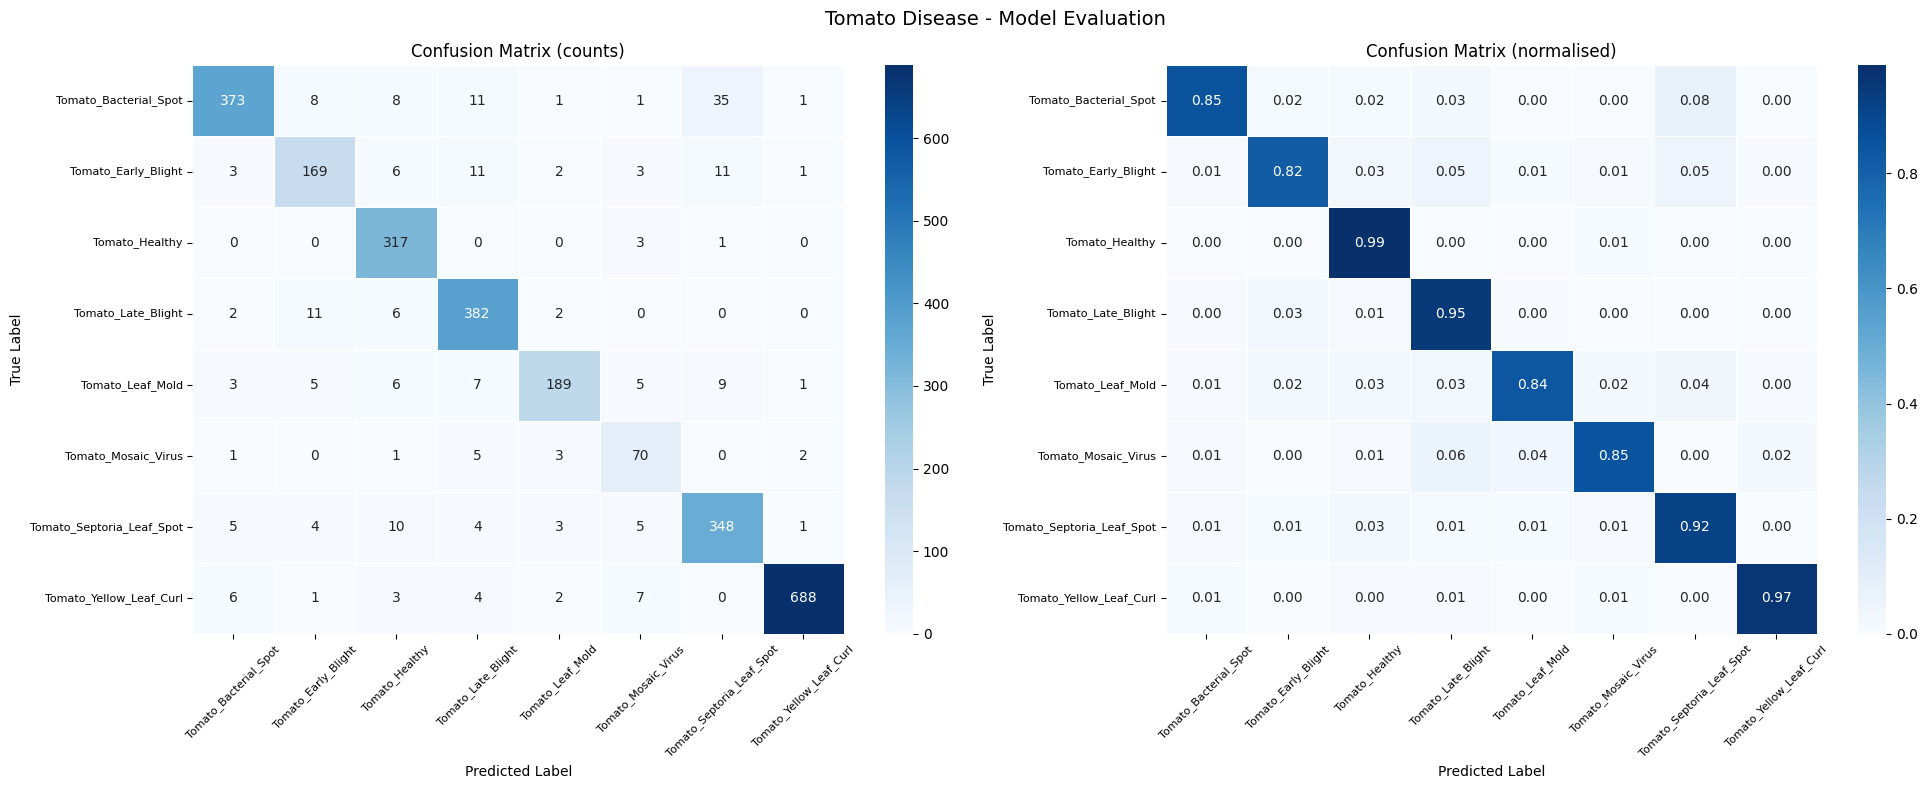

In [17]:
def plot_confusion_matrix(y_true, y_pred, class_names):
    cm      = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    for ax, data, title, fmt in [
        (axes[0], cm,      "Confusion Matrix (counts)",     "d"),
        (axes[1], cm_norm, "Confusion Matrix (normalised)", ".2f"),
    ]:
        sns.heatmap(data, annot=True, fmt=fmt, cmap="Blues",
                    xticklabels=class_names, yticklabels=class_names,
                    ax=ax, linewidths=0.5)
        ax.set_title(title, fontsize=12)
        ax.set_ylabel("True Label")
        ax.set_xlabel("Predicted Label")
        ax.tick_params(axis="x", rotation=45, labelsize=8)
        ax.tick_params(axis="y", rotation=0,  labelsize=8)

    plt.suptitle("Tomato Disease - Model Evaluation", fontsize=14)
    plt.tight_layout()
    plt.savefig(LOGS_DIR / "confusion_matrix.png", dpi=150, bbox_inches="tight")
    plt.show()

plot_confusion_matrix(y_true, y_pred, CLASS_NAMES)

###  Export Model + Version Registry

In [ ]:
import yaml

timestamp  = datetime.datetime.now().strftime("%Y%m%d_%H%M")
version_id = f"v1_{timestamp}"

model_filename = f"tomato_efficientnetb0_{version_id}.keras"
model_path     = MODELS_DIR / model_filename
model.save(model_path)
print(f"Model saved       : {model_path}")

model_config = {
    "version"             : version_id,
    "model_file"          : model_filename,
    "architecture"        : "EfficientNetB0",
    "input_size"          : list(IMG_SIZE),
    "num_classes"         : NUM_CLASSES,
    "class_names"         : CLASS_NAMES,
    "preprocessing"       : "efficientnet",
    "thresholds"          : {
        "confident"       : THRESHOLD_CONFIDENT,
        "uncertain"       : THRESHOLD_UNCERTAIN,
    },
    "trained_on"          : "PlantDoc + PlantVillage (tomato subset, pooled)",
    "training_date"       : timestamp,
    "val_accuracy"        : round(float(best_val_acc), 4),
    "fine_tune_from_layer": FINE_TUNE_FROM,
}

config_path = MODELS_DIR / f"model_config_{version_id}.yaml"
with open(config_path, "w") as f:
    yaml.dump(model_config, f, default_flow_style=False, sort_keys=False)
print(f"Config saved      : {config_path}")

registry_path = MODELS_DIR / "registry.json"
registry = []
if registry_path.exists():
    with open(registry_path) as f:
        registry = json.load(f)

registry.append({
    **model_config,
    "per_class_metrics": {
        cls: {
            "precision" : round(report_dict[cls]["precision"], 4),
            "recall"    : round(report_dict[cls]["recall"], 4),
            "f1"        : round(report_dict[cls]["f1-score"], 4),
            "support"   : int(report_dict[cls]["support"]),
        }
        for cls in CLASS_NAMES
    },
    "is_active": True,
})

with open(registry_path, "w") as f:
    json.dump(registry, f, indent=2)
print(f"Registry updated  : {registry_path}")

### Files to Download

In [ ]:
print("\n" + "=" * 60)
print("Download these files from Kaggle output:")
print("=" * 60)
for f in sorted(MODELS_DIR.iterdir()):
    size_mb = f.stat().st_size / (1024 * 1024)
    print(f"  {f.name:<55} {size_mb:>7.2f} MB")
print()
for f in sorted(LOGS_DIR.iterdir()):
    size_mb = f.stat().st_size / (1024 * 1024)
    print(f"  logs/{f.name:<51} {size_mb:>7.2f} MB")
print("""
Put them in your local project:
  saved_models/tomato_efficientnetb0_<version>.keras
  saved_models/registry.json
  training/configs/model_config_<version>.yaml
""")

### Sanity Check

In [ ]:
from tensorflow.keras.preprocessing import image as keras_image

loaded_model = keras.models.load_model(model_path)
print(f"Model loaded: {model_path.name}")

def predict_single(img_path, model, class_names, thresholds):
    img = keras_image.load_img(img_path, target_size=IMG_SIZE)
    arr = keras_image.img_to_array(img)
    arr = np.expand_dims(arr, axis=0)
    # EfficientNetB0: no preprocessing — raw [0, 255] pixels

    probs      = model.predict(arr, verbose=0)[0]
    top_idx    = np.argsort(probs)[::-1]
    confidence = float(probs[top_idx[0]])
    pred_class = class_names[top_idx[0]]

    if confidence >= thresholds["confident"]:
        status = "CONFIDENT"
    elif confidence >= thresholds["uncertain"]:
        status = "UNCERTAIN"
    else:
        status = "FAILED"

    return {
        "predicted_class": pred_class,
        "confidence"     : round(confidence, 4),
        "status"         : status,
        "top_k"          : [
            {"class": class_names[i], "confidence": round(float(probs[i]), 4)}
            for i in top_idx[:3]
        ],
    }

thresholds  = {"confident": THRESHOLD_CONFIDENT, "uncertain": THRESHOLD_UNCERTAIN}
sample_imgs = list(DATA_DIR.rglob("*.jpg")) + list(DATA_DIR.rglob("*.png"))
import random; random.shuffle(sample_imgs)

print(f"\n{'Image':<45} {'Pred':<30} {'Conf':>6} {'Status'}")
print("-" * 100)
for img_path in sample_imgs[:5]:
    result = predict_single(img_path, loaded_model, CLASS_NAMES, thresholds)
    print(f"{img_path.name:<45} {result['predicted_class']:<30} "
          f"{result['confidence']:>6.3f}  {result['status']}")